In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [5]:
from matplotlib import rcParams
# 配置 matplotlib 使用中文字体
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()    


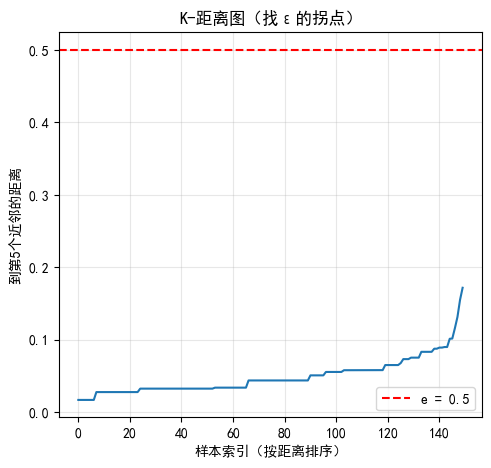

In [6]:
# ---------------------- 1. 数据准备 ----------------------
from sklearn.preprocessing import MinMaxScaler


iris = load_iris()
x = iris.data[:,[0,2]]  # 取2个特征（花萼长度、花瓣长度），方便可视化
ytrue = iris.target  # 真实标签（仅用于对比，DBSCAN不使用）
# DBSCAN对数据尺度敏感，先标准化（均值0，方差1）
x_scaled = MinMaxScaler().fit_transform(x)
# ---------------------- 2. 调参：确定ε（K-距离图） ----------------------
# 选择MinPts=5（二维数据，MinPts=维度+1）
min_pts=5
nbor = NearestNeighbors(n_neighbors=min_pts)
model = nbor.fit(x_scaled)

# 计算每个样本到第min_pts个近邻的距离
distance,_ = model.kneighbors(x_scaled)
distance = np.sort(distance[:,min_pts-1],axis=0)
# 绘制K-距离图，找“拐点”（ε的最佳值）
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(distance)
plt.xlabel('样本索引（按距离排序）')
plt.ylabel(f'到第{min_pts}个近邻的距离')
plt.title('K-距离图（找ε的拐点）')
plt.grid(alpha=0.3)
plt.axhline(y=0.5,color='r',linestyle='--',label='e = 0.5')# 拐点位置
plt.legend()



In [7]:
# ---------------------- 3. 训练DBSCAN ----------------------
eps = 0.5
dbscan = DBSCAN(eps=eps,min_samples=min_pts)
ypred = dbscan.fit_predict(x_scaled)
# 查看聚类结果：-1表示噪声点
unique_lbls = np.unique(ypred)
n_clusters = len(unique_lbls)-(1 if -1 in unique_lbls else 0)
n_noise = list(ypred).count(-1)
print(f"检测到的簇数量：{n_clusters}")
print(f"噪声点数量：{n_noise}")



检测到的簇数量：1
噪声点数量：0


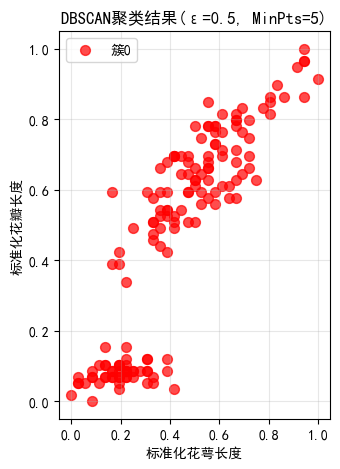

In [8]:
# ---------------------- 4. 可视化聚类结果 ----------------------
plt.subplot(1,2,1)
# 定义颜色（噪声点用黑色）
colors = ['red', 'green', 'blue', 'black']
labels = [f"簇{i}" for i in range(n_clusters)]+ ['噪声']
for i,label in enumerate(unique_lbls):
    # 绘制对应簇的样本
    mask = ypred == label
    plt.scatter(x_scaled[mask,0],x_scaled[mask,1],c=colors[i],label=labels[i],s=50,alpha=0.7)
plt.xlabel('标准化花萼长度')
plt.ylabel('标准化花瓣长度')
plt.title(f'DBSCAN聚类结果(ε={eps}, MinPts={min_pts})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
"""
六、 代码关键解释
数据标准化:DBSCAN 基于距离计算密度，特征尺度差异会导致距离计算偏差（如厘米级和毫米级特征），标准化是必须的；
K - 距离图调参：这是确定 ε 的核心方法 —— 图中 “拐点” 处的距离就是最优 ε（拐点前距离快速上升，拐点后趋于平缓）；
结果解读: fit_predict返回的标签中,-1代表噪声点,其余整数代表不同的簇；
可视化：二维特征下能直观看到 DBSCAN 识别的任意形状簇（对比 K-Means 只能识别圆形簇）。
总结
核心优势: DBSCAN 是无参数（无需预设 K)、能识别任意形状簇、可检测噪声的密度聚类算法，适合处理非凸分布的真实数据；
调参关键：通过 K - 距离图确定 ε,MinPts 通常设为 “数据维度 + 1”;
适用场景：地理空间数据（如 GPS 轨迹聚类）、异常检测（如欺诈交易识别）、非凸分布的高维数据（需先降维）。
"""